In [1]:
from server.inference import (
    qwen_chat_prompt, 
    CausalModel, 
    EncoderModel,
    InferenceModelResourceManager
)

CLASSIFIER_MODEL = "Qwen/Qwen3.5-4B"
ENCODER_MODEL = "Qwen/Qwen3-Embedding-0.6B"

resource_manager = InferenceModelResourceManager(quota_gb=15)
completion_model = CausalModel(
    CLASSIFIER_MODEL, qwen_chat_prompt, resource_manager, mem_required_gb=5
)
encoder_model = EncoderModel(
    ENCODER_MODEL, resource_manager, mem_required_gb=1
)

In [2]:
from pathlib import Path
from server.representations.scene_representation import _parse_sections

text = Path("./data/story_2.md").read_text()
sections = _parse_sections(text)

21:19:52  33814 resource_manager Preparing Qwen/Qwen3-Embedding-0.6B for serving ...
21:19:53  33814 httpx        HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-Embedding-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:19:53  33814 httpx        HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-Embedding-0.6B/97b0c614be4d77ee51c0cef4e5f07c00f9eb65b3/config.json "HTTP/1.1 200 OK"


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 1047.78it/s]


21:19:54  33814 httpx        HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-Embedding-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:19:54  33814 httpx        HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-Embedding-0.6B/97b0c614be4d77ee51c0cef4e5f07c00f9eb65b3/config.json "HTTP/1.1 200 OK"
21:19:55  33814 httpx        HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-Embedding-0.6B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
21:19:55  33814 httpx        HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-Embedding-0.6B/97b0c614be4d77ee51c0cef4e5f07c00f9eb65b3/tokenizer_config.json "HTTP/1.1 200 OK"
21:19:55  33814 httpx        HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3-Embedding-0.6B/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
21:19:55  33814 httpx        HTTP Request: GET https://huggingface.co/api/models/Qwen

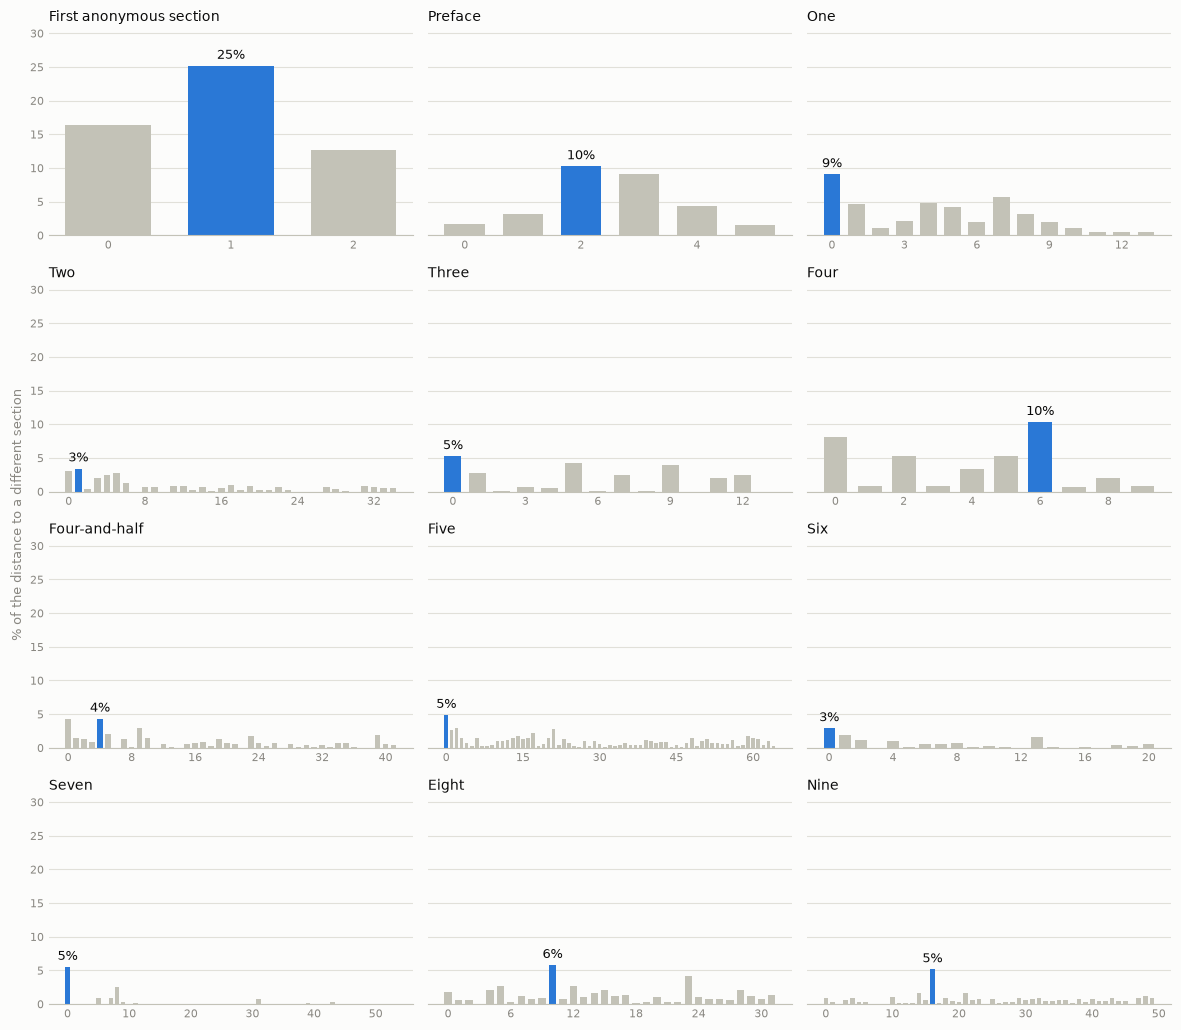

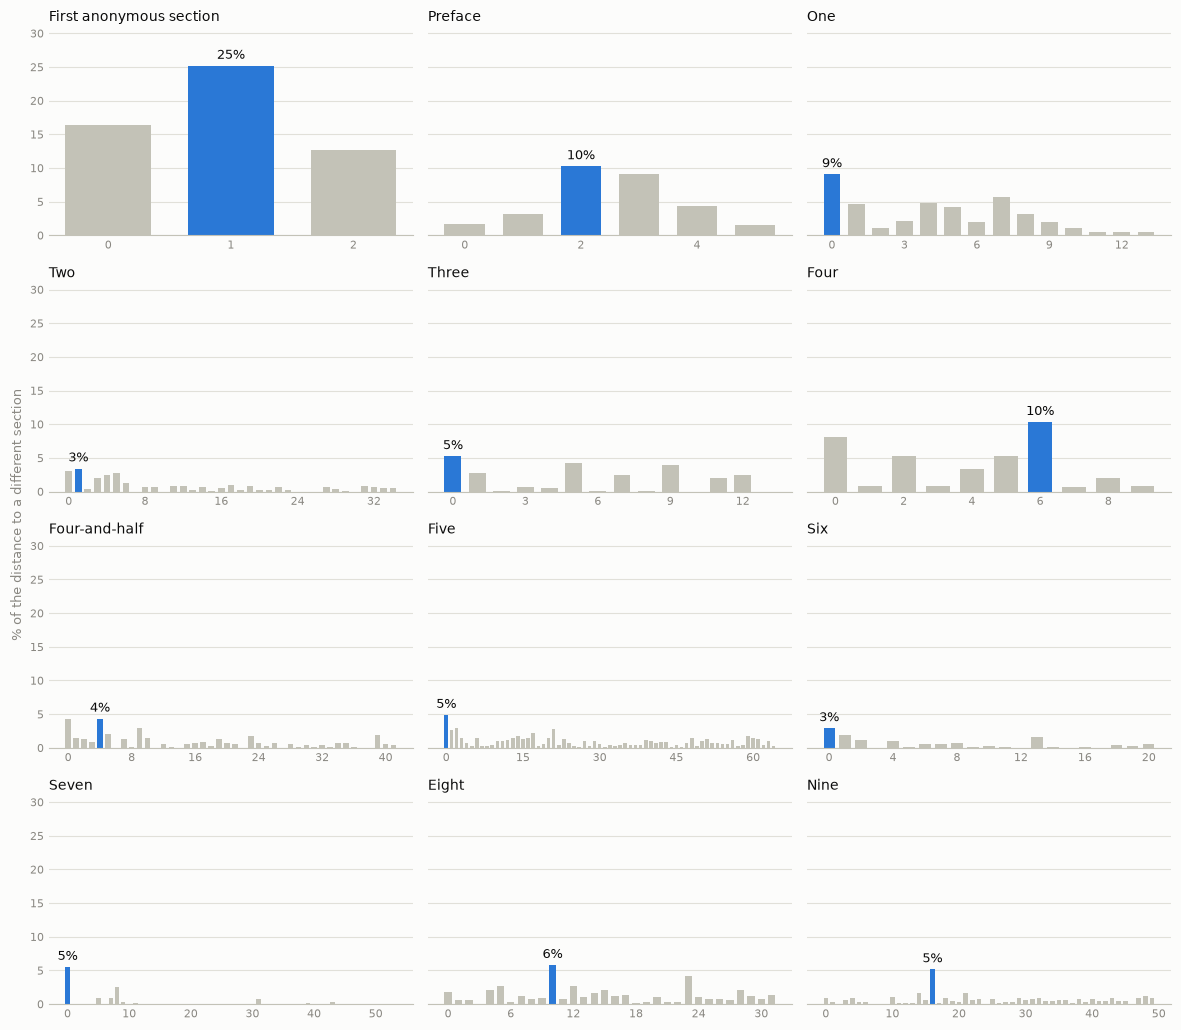

In [4]:
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

def section_line_importances(encoder, doc_lines, sections):
    kept = [[l for l in doc_lines[s.start:s.end + 1] if l.strip()] for s in sections]
    section_vectors = np.asarray(encoder.encode(["\n".join(k) for k in kept]))
    results = []
    for i, (s, k) in enumerate(zip(sections, kept)):
        if len(k) < 2:
            results.append((s, k, np.zeros(len(k))))
            continue
        variants = ["\n".join(k[:j] + k[j + 1:]) for j in range(len(k))]
        ablated = np.asarray(encoder.encode(variants))
        full = section_vectors[i]
        others = np.delete(section_vectors, i, axis=0)
        ceiling = np.median(1.0 - others @ full) if len(others) else 1.0
        results.append((s, k, 100.0 * (1.0 - ablated @ full) / ceiling))
    return results


SURFACE, GRID, BASELINE, MUTED, INK = "#fcfcfb", "#e1e0d9", "#c3c2b7", "#898781", "#0b0b0b"
ACCENT, REST = "#2a78d6", "#c3c2b7"
def plot_importance_grid(results, ncols=3):
    n = len(results)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.6 * nrows),
                             sharey=True, squeeze=False)
    fig.patch.set_facecolor(SURFACE)
    top = max((pct.max() for _, _, pct in results if len(pct)), default=1.0) * 1.2

    for ax, (s, k, pct) in zip(axes.flat, results):
        ax.set_facecolor(SURFACE)
        lead = int(np.argmax(pct)) if len(pct) else 0
        ax.bar(range(len(pct)), pct, width=0.7, linewidth=0,
               color=[ACCENT if j == lead else REST for j in range(len(pct))])
        if len(pct):
            ax.annotate(f"{pct[lead]:.0f}%", (lead, pct[lead]), ha="center", va="bottom",
                        xytext=(0, 3), textcoords="offset points", fontsize=9, color=INK)
        ax.set_title(s.title[:38], loc="left", fontsize=10, color=INK, pad=8)
        ax.set_ylim(0, top)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(BASELINE)
        ax.tick_params(colors=MUTED, labelsize=8, length=0)

    for ax in axes.flat[n:]:
        ax.set_visible(False)
    fig.supylabel("% of the distance to a different section", color=MUTED, fontsize=9)
    fig.tight_layout()
    return fig

lines = text.splitlines()
results = section_line_importances(encoder_model, lines, sections)
plot_importance_grid(results)